/home/jane/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/jane/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


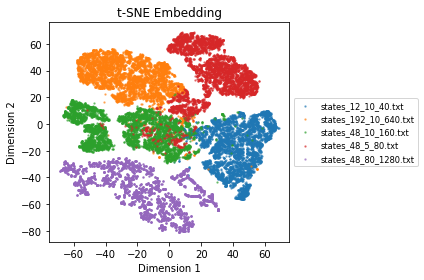

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt

# Store all vectors for global normalization
directory = '/home/jane/Documents/Orca/orca_tsne_experiment'
all_vectors = []
file_labels = []

# Read all state files and store the vectors
for filename in os.listdir(directory):
    if filename.endswith('.txt'):
        file_path = os.path.join(directory, filename)
        with open(file_path, 'r') as f:
            data = f.read()
            vectors_str = data.split('[')[1:]
            for vector_str in vectors_str:
                vector = np.fromstring(vector_str.split(']')[0], sep=' ')
                if np.count_nonzero(vector) != 0:  # Ignore empty vectors
                    all_vectors.append(vector)
                    file_labels.append(filename)  # Keep track of which file each vector belongs to

# Normalize across all environments
all_vectors = np.array(all_vectors)
scaler = StandardScaler()
all_vectors_normalized = scaler.fit_transform(all_vectors)

# Chose perplexity of 50 within the recommended range of 5-50
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
embeddings = tsne.fit_transform(all_vectors_normalized)



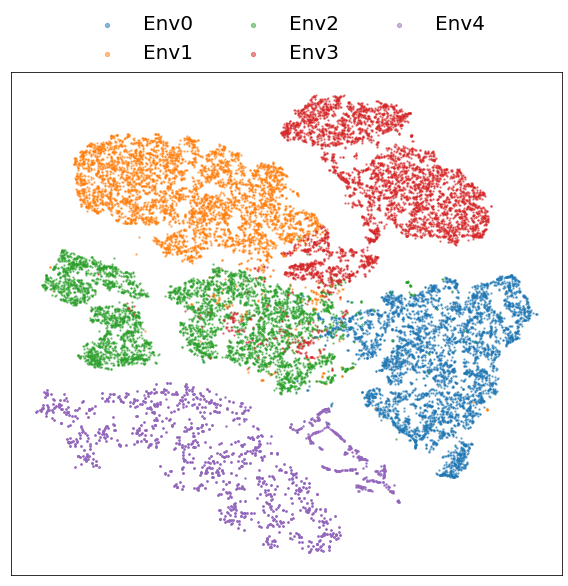

In [21]:
# Plot the embeddings with different colors per environment
fig, ax = plt.subplots(figsize=(8, 8))
ax.xaxis.set_major_locator(plt.NullLocator())
ax.yaxis.set_major_locator(plt.NullLocator())
unique_files = np.unique(file_labels)
for i, filename in enumerate(unique_files):
    indices = [idx for idx, label in enumerate(file_labels) if label == filename]
    ax.scatter(embeddings[indices, 0], embeddings[indices, 1], label="Env"+str(i), s=2, alpha=0.5)

# Set labels and title
# ax.set_xlabel('Dimension 1', fontsize=20)
# ax.set_ylabel('Dimension 2', fontsize=20)
# ax.set_xticks(fontsize=18)
# ax.set_yticks(fontsize=18)
# ax.set_title('t-SNE Embedding')

# Add legend outside of the plot
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
# plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.25), ncol=4, fontsize=20, frameon=False)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), 
           ncol=3, fontsize=20, markerscale=3, frameon=False)

plt.subplots_adjust(top=0.85, bottom=0.18, left=0.1, right=0.98)
# Show the plot
plt.tight_layout()
plt.savefig('/home/jane/Downloads/orca_tsne.png')
plt.show()